### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd

sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [2]:
sessions_count = sessions_history.groupby('user_id')['session_id'].nunique()
top_user = sessions_count.idxmax()
sessions_history[sessions_history['user_id'] == top_user]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

In [3]:
# считаем уникальных пользователей по дням
day_stats = sessions_history.groupby('session_date').agg(unique_users=('user_id', 'nunique')).reset_index()

# считаем зарегистрированных пользователей по дням
registered_day = sessions_history[sessions_history['registration_flag'] == 1].groupby('session_date').agg(
    registered_users=('user_id', 'nunique')).reset_index()

# объединяем подсчитанные значения
day_stats = day_stats.merge(registered_day, on='session_date', how='left')

# заполняем дни без регистраций нулями, чтобы убрать пропуски
day_stats['registered_users'] = day_stats['registered_users'].fillna(0).astype(int)

day_stats['session_date'] = pd.to_datetime(day_stats['session_date'])

day_stats

,session_date,unique_users,registered_users
0,2025-08-11,3919,169
1,2025-08-12,6056,336
2,2025-08-13,8489,464
3,2025-08-14,10321,625
4,2025-08-15,14065,840
5,2025-08-16,12205,916
6,2025-08-17,11200,833
7,2025-08-18,10839,860
8,2025-08-19,12118,831
9,2025-08-20,13514,1008


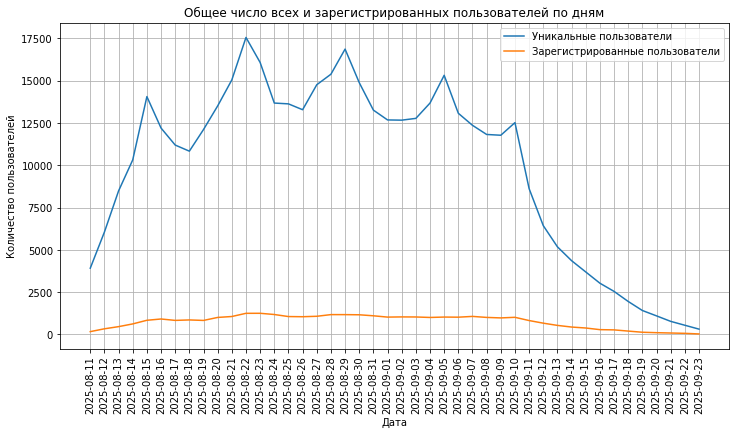

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns 


plt.figure(figsize=(12, 6)) 

plt.plot(
    day_stats['session_date'],
    day_stats['unique_users'],
    label='Уникальные пользователи')

plt.plot(
    day_stats['session_date'],
    day_stats['registered_users'],
    label='Зарегистрированные пользователи') 

# настраиваем вид графика
plt.title('Общее число всех и зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid()
plt.xticks(day_stats['session_date'], rotation=90)

plt.show()

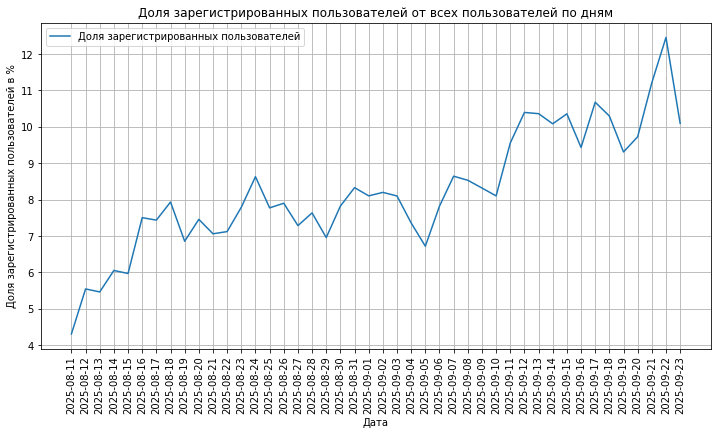

In [5]:
# считаем долю зарегистрированных пользователей
day_stats['registered_share'] = day_stats['registered_users'] / day_stats['unique_users'] * 100

plt.figure(figsize=(12, 6))

plt.plot(
    day_stats['session_date'],
    day_stats['registered_share'],
    label='Доля зарегистрированных пользователей')

# настраиваем вид графика
plt.title('Доля зарегистрированных пользователей от всех пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля зарегистрированных пользователей в %')
plt.legend()
plt.grid()
plt.xticks(day_stats['session_date'], rotation=90)

plt.show()

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 8978 первых сессиях, две страницы — в 32 494 первых сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

In [6]:
page_stats = sessions_history[sessions_history['session_number'] == 1]['page_counter'].value_counts().reset_index()
page_stats.columns = ['page_counter', 'first_sessions_count']
page_stats = page_stats.sort_values('page_counter').reset_index(drop=True)

page_stats

,page_counter,first_sessions_count
0,1,8978
1,2,32494
2,3,50939
3,4,32739
4,5,8075
5,6,777
6,7,37


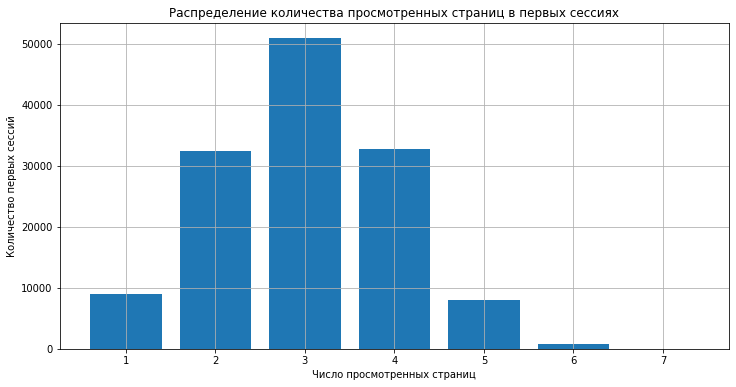

In [7]:
plt.figure(figsize=(12, 6))

plt.bar(
    page_stats['page_counter'],
    page_stats['first_sessions_count'])

# настраиваем вид графика
plt.title('Распределение количества просмотренных страниц в первых сессиях')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество первых сессий')
plt.grid() 

plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

In [8]:
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)
# проверяем результат
sessions_history.head(10)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,0
5,835DD33FC86B3584,3AC48B25BA586DB3,2025-08-15,2025-08-15 18:03:05,2025-08-15,1,0,3,MENA,Android,0
6,AE22C619172A9E28,F1A345355A8981FD,2025-08-15,2025-08-15 23:20:57,2025-08-15,1,0,3,MENA,Android,0
7,2D63C6E7B6D5691B,8EC5B17CA1ED5E10,2025-08-15,2025-08-15 14:45:02,2025-08-15,1,0,5,MENA,PC,1
8,4FFA441542A50124,E99DF62E41ECAB10,2025-08-15,2025-08-15 18:28:23,2025-08-15,1,0,4,CIS,iPhone,1
9,61DCA6C89DA4288D,3F870A71E087CFE6,2025-08-15,2025-08-15 18:58:52,2025-08-15,1,0,5,CIS,Android,1


In [9]:
# выбираем только первые сессии
first_sessions = sessions_history[sessions_history['session_number'] == 1].copy()

# группируем по дням и считаем количество всех и успешных сессий
day_first_sessions = first_sessions.groupby('session_date').agg(
    total_first_sessions=('session_id', 'count'),
    good_first_sessions=('good_session', 'sum')).reset_index()

# считаем долю успешных первых сессий
day_first_sessions['good_share'] = (day_first_sessions['good_first_sessions'] / day_first_sessions['total_first_sessions'] * 100)
day_first_sessions = day_first_sessions.sort_values('session_date').reset_index(drop=True)
day_first_sessions['session_date'] = pd.to_datetime(day_first_sessions['session_date'])

day_first_sessions


,session_date,total_first_sessions,good_first_sessions,good_share
0,2025-08-11,3919,1226,31.283491
1,2025-08-12,4106,1225,29.834389
2,2025-08-13,5087,1561,30.686063
3,2025-08-14,5456,1741,31.909824
4,2025-08-15,7801,2427,31.111396
5,2025-08-16,3787,1168,30.842355
6,2025-08-17,2978,951,31.934184
7,2025-08-18,3079,964,31.308867
8,2025-08-19,4412,1387,31.436990
9,2025-08-20,5215,1612,30.910834


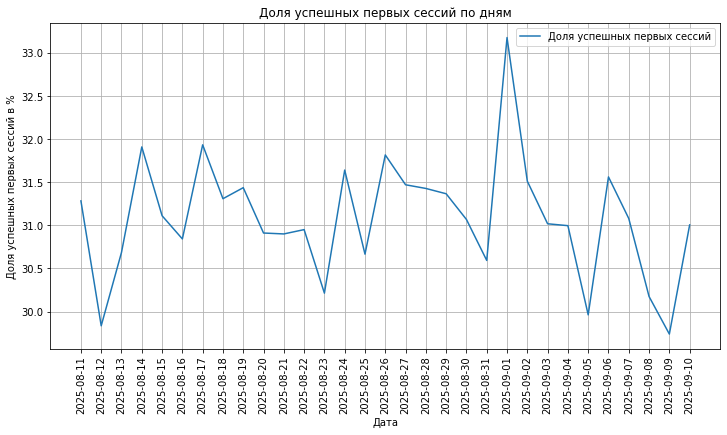

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(
    day_first_sessions['session_date'],
    day_first_sessions['good_share'],
    label='Доля успешных первых сессий')

# настраиваем вид графика
plt.title('Доля успешных первых сессий по дням')
plt.xlabel('Дата')
plt.ylabel('Доля успешных первых сессий в %')
plt.legend()
plt.grid()
plt.xticks(day_first_sessions['session_date'], rotation=90)

plt.show()

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [11]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import *

# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p * (1 + mde))

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [12]:
from math import ceil


# Среднее количество пользователей приложения в день по историческим данным
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])
daily_users = sessions_history.groupby('session_date')['user_id'].nunique().reset_index()
daily_users.columns = ['session_date', 'unique_users']
avg_daily_users = daily_users['unique_users'].mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size*2/avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [13]:
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')
sessions_test_part['session_date'] = pd.to_datetime(sessions_test_part['session_date'])
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [14]:
group_stats = sessions_test_part.groupby('test_group')['user_id'].nunique().reset_index()
group_stats.columns = ['test_group', 'unique_users']
group_stats

,test_group,unique_users
0,A,1477
1,B,1466


In [15]:
users_A_count = group_stats[group_stats['test_group'] == 'A']['unique_users'].values[0]
users_B_count = group_stats[group_stats['test_group'] == 'B']['unique_users'].values[0]

diff = 100 * abs(users_A_count - users_B_count) / users_A_count

print(f"Количество пользователей в группе A: {users_A_count}")
print(f"Количество пользователей в группе B: {users_B_count}")
print(f"Процентная разница: {diff}%")

Количество пользователей в группе A: 1477
Количество пользователей в группе B: 1466
Процентная разница: 0.7447528774542993%


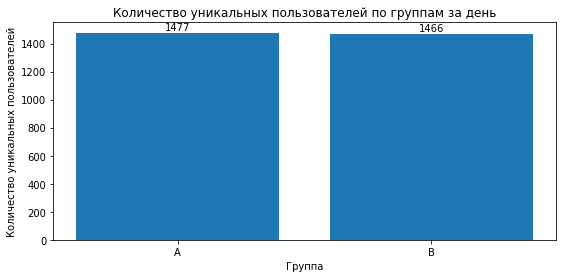

In [16]:
plt.figure(figsize=(9, 4))
bars = plt.bar(
                group_stats['test_group'], 
                group_stats['unique_users'])
plt.title('Количество уникальных пользователей по группам за день')
plt.ylabel('Количество уникальных пользователей')
plt.xlabel('Группа')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom')

plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [17]:
users_A = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'])
users_B = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'])

int_users = users_A & users_B
count_int = len(int_users)

count_int

0

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


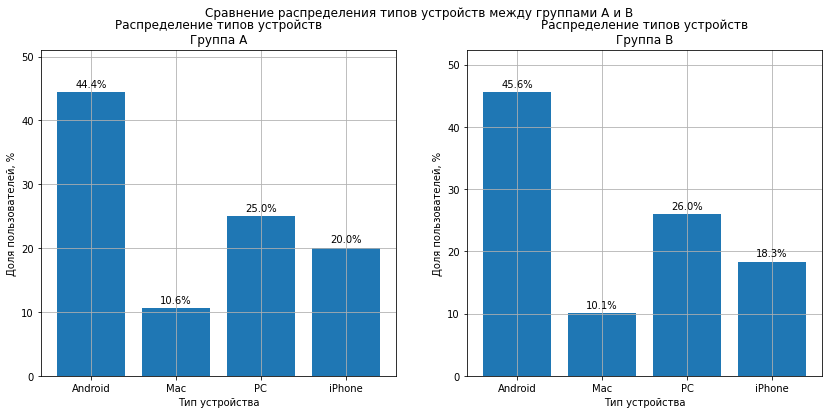

In [18]:
group_A = sessions_test_part[sessions_test_part['test_group'] == 'A']
group_B = sessions_test_part[sessions_test_part['test_group'] == 'B']

# для каждой группы считаем уникальных пользователей по каждому устройству
device_A = group_A.groupby('device')['user_id'].nunique().reset_index()
device_A.columns = ['device', 'users_count']
device_A['percent'] = device_A['users_count'] / device_A['users_count'].sum() * 100

device_B = group_B.groupby('device')['user_id'].nunique().reset_index()
device_B.columns = ['device', 'users_count']
device_B['percent'] = device_B['users_count'] / device_B['users_count'].sum() * 100

# строим диаграммы
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# диаграмма для группы A
barsA = ax1.bar(device_A['device'], device_A['percent'])
ax1.set_title('Распределение типов устройств\nГруппа A')
ax1.set_ylabel('Доля пользователей, %')
ax1.set_xlabel('Тип устройства')

for bar in barsA:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
              f'{height:.1f}%', ha='center', va='bottom')

ax1.grid()
ax1.set_ylim(0, max(device_A['percent']) * 1.15)

# диаграмма для группы B
barsB = ax2.bar(device_B['device'], device_B['percent'])
ax2.set_title('Распределение типов устройств\nГруппа B')
ax2.set_ylabel('Доля пользователей, %')
ax2.set_xlabel('Тип устройства')

for bar in barsB:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
              f'{height:.1f}%', ha='center', va='bottom')

ax2.grid()
ax2.set_ylim(0, max(device_B['percent']) * 1.15)

plt.suptitle('Сравнение распределения типов устройств между группами A и B')
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

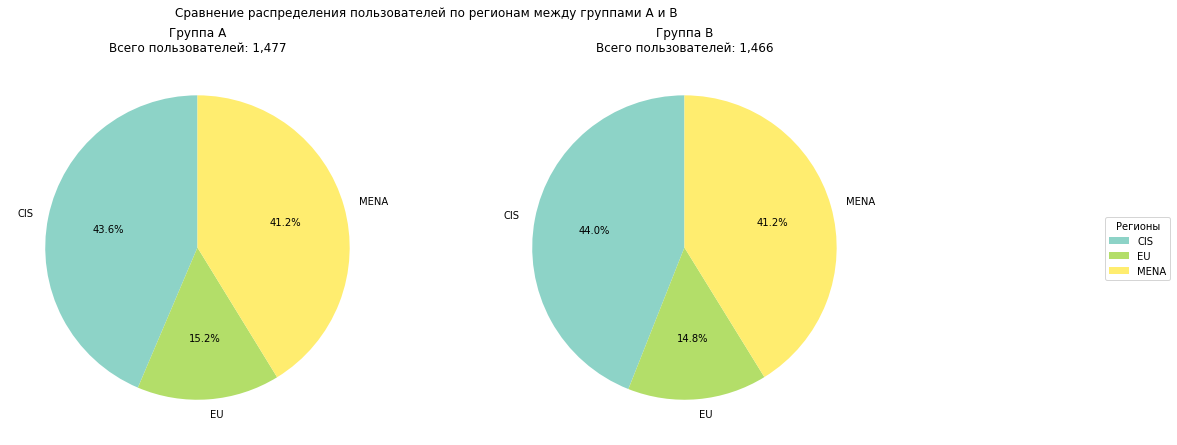

In [19]:
group_A = sessions_test_part[sessions_test_part['test_group'] == 'A']
group_B = sessions_test_part[sessions_test_part['test_group'] == 'B']

# считаем уникальных пользователей по регионам для каждой группы
region_A = group_A.groupby('region')['user_id'].nunique().reset_index()
region_A.columns = ['region', 'users_count']
region_A['percent'] = region_A['users_count'] / region_A['users_count'].sum() * 100

region_B = group_B.groupby('region')['user_id'].nunique().reset_index()
region_B.columns = ['region', 'users_count']
region_B['percent'] = region_B['users_count'] / region_B['users_count'].sum() * 100

# единую цветовая схема для регионов
all_regions = sorted(set(region_A['region']) | set(region_B['region']))
colors = plt.cm.Set3(np.linspace(0, 1, len(all_regions)))
color_dict = {region: colors[i] for i, region in enumerate(all_regions)}

# строим круговые диаграммы
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Сравнение распределения пользователей по регионам между группами A и B')

# диаграмма для группы A
colors_A = [color_dict[r] for r in region_A['region']]
wedgesA, textsA, autotextsA = ax1.pie(
    region_A['percent'],
    labels=region_A['region'],
    autopct=lambda pct: f'{pct:.1f}%' if pct > 2 else '',
    colors=colors_A,
    startangle=90,
    textprops={'fontsize': 10}
)
ax1.set_title(f'Группа A\nВсего пользователей: {region_A["users_count"].sum():,}')

# диаграмма для группы B
colors_B = [color_dict[r] for r in region_B['region']]
wedgesB, textsB, autotextsB = ax2.pie(
    region_B['percent'],
    labels=region_B['region'],
    autopct=lambda pct: f'{pct:.1f}%' if pct > 2 else '',
    colors=colors_B,
    startangle=90,
    textprops={'fontsize': 10}
)
ax2.set_title(f'Группа B\nВсего пользователей: {region_B["users_count"].sum():,}')

# Общая легенда
fig.legend(wedgesA, all_regions,
           title="Регионы",
           loc="center right",
           bbox_to_anchor=(1.15, 0.5))

plt.show()

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

**Вывод проверки A/B-теста**

1. количество пользователей в обеих группах примерно равное (в группе А - 1477, в группе В - 1466),  разница в объемах групп составляет 0,7%, что является статистически приемлемым. 
2. Выборки являются независимыми. Пересечение пользователей между группами А и В отсутствует (каждый пользователь участвует только в одной группе). Это соответствует основному требованию корректного A/B-теста.
3. Распределение пользователей групп по категориальным переменным: 
- устройства: распределение практически одинаковое, в обеих группах лидирует Android (в группе А - 43,7%, в группе В - 44,4%). Максимальное расхождение составляет 1,6% (по iOS), что находится в допустимых пределах.
- регионы: распределение пользователей по регионам сопоставимо. Максимальное расхождение составляет 6,1%. Несмотря на то, что это расхождение несколько больше, чем по устройствам, оно не является критическим и может объясняться естественной вариативностью выборки.

A/B-тест проходит корректно, нарушения не наблюдаются. Все ключевые метрики (равенство групп, независимость выборок, распределение по категориальным признакам) находятся в допустимых пределах. 

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [20]:
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')
sessions_test['session_date'] = pd.to_datetime(sessions_test['session_date'])
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


In [21]:
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)
# проверяем результат
sessions_history.head(10)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,0
5,835DD33FC86B3584,3AC48B25BA586DB3,2025-08-15,2025-08-15 18:03:05,2025-08-15,1,0,3,MENA,Android,0
6,AE22C619172A9E28,F1A345355A8981FD,2025-08-15,2025-08-15 23:20:57,2025-08-15,1,0,3,MENA,Android,0
7,2D63C6E7B6D5691B,8EC5B17CA1ED5E10,2025-08-15,2025-08-15 14:45:02,2025-08-15,1,0,5,MENA,PC,1
8,4FFA441542A50124,E99DF62E41ECAB10,2025-08-15,2025-08-15 18:28:23,2025-08-15,1,0,4,CIS,iPhone,1
9,61DCA6C89DA4288D,3F870A71E087CFE6,2025-08-15,2025-08-15 18:58:52,2025-08-15,1,0,5,CIS,Android,1


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

**Целевая метрика**\
Ключевой метрикой является вовлеченность пользователей, которая отражает, насколько новый алгоритм рекомендаций повышает интерес пользователей. В качестве конкретной метрики можно использовать: среднее количество просмотренных страниц на пользователя

**Нулевая и альтернативная гипотезы** \
H₀ (Нулевая гипотеза): Новый алгоритм рекомендаций не оказывает значимого влияния на вовлеченность пользователей. Среднее количество просмотров на пользователя в группе B (с новым алгоритмом) не отличается от группы A (со старым алгоритмом).

H₀: μ_B = μ_A

H₁ (Альтернативная гипотеза): Новый алгоритм рекомендаций значительно повышает вовлеченность пользователей. Среднее количество просмотров на пользователя в группе B выше, чем в группе A.

H₁: μ_B > μ_A

**Прокси-метрики**

* Доля пользователей, сделавших лайк
* Среднее количество регистраций в день
* Доля контента, досмотренных до конца
* Средняя продолжительность просмотра контента
* Доля пролистнутого (непросмотроенного) контента

**Барьерные метрики**

* Доля пользователей, покинувших приложение после просмотра всего 1 страницы
* Частота технических ошибок/сбоев
* Среднее время загрузки контента
* Количество обращений в техническую поддержку

#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [22]:
group_A = sessions_test[sessions_test['test_group'] == 'A']
group_B = sessions_test[sessions_test['test_group'] == 'B']

first_sessions_A = group_A[group_A['session_number'] == 1].copy()
first_sessions_B = group_B[group_B['session_number'] == 1].copy()

good_share_A = first_sessions_A['good_session'].mean() * 100
good_share_B = first_sessions_B['good_session'].mean() * 100

diff = good_share_B - good_share_A

print(f"Доля успешных первых сессий в группе А: {good_share_A}%")
print(f"Доля успешных первых сессий в группе В: {good_share_B}%")
print(f"Разница (B - A): {diff}%")

Доля успешных первых сессий в группе А: 31.572351932462734%
Доля успешных первых сессий в группе В: 31.467306694343538%
Разница (B - A): -0.10504523811919597%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных первых сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [23]:
from statsmodels.stats.proportion import proportions_ztest

df_exp = sessions_test[sessions_test['session_number'] == 1].copy()

# размеры групп
n_a = df_exp[df_exp['test_group'] == 'A'].shape[0]
n_b = df_exp[df_exp['test_group'] == 'B'].shape[0]

# количество успехов
m_a = df_exp[(df_exp['test_group'] == 'A') & (df_exp['good_session'] == 1)].shape[0]
m_b = df_exp[(df_exp['test_group'] == 'B') & (df_exp['good_session'] == 1)].shape[0]

# доли успехов
p_a, p_b = m_a / n_a, m_b / n_b

# проверка предпосылки о достаточном количестве данных
if (p_a * n_a > 10) and ((1 - p_a) * n_a > 10) and (p_b * n_b > 10) and ((1 - p_b) * n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

alpha = 0.05

# односторонний Z-тест (B > A)
stat_ztest, p_value_ztest = proportions_ztest(
    [m_b, m_a],
    [n_b, n_a],
    alternative='larger'
)

print(f'p-value = {p_value_ztest}')

if p_value_ztest > alpha:
    print('Нулевая гипотеза находит подтверждение!')
    text_interpretation = 'не изменилась'
else:
    print('Нулевая гипотеза не находит подтверждения!')
    if p_b > p_a:
        text_interpretation = 'увеличилась'
    else:
        text_interpretation = 'сократилась'

print(f'При использовании нового алгоритма рекомендаций доля успешных первых сессий {text_interpretation} (с {p_a*100:.2f}% до {p_b*100:.2f}%)')

Предпосылка о достаточном количестве данных выполняется!
p-value = 0.5783523649187868
Нулевая гипотеза находит подтверждение!
При использовании нового алгоритма рекомендаций доля успешных первых сессий не изменилась (с 31.57% до 31.47%)


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

**В ходе A/B-эксперимента были две группы:**\
Группа A (контрольная) — старый алгоритм рекомендаций\
Группа B (тестовая) — новый алгоритм рекомендаций

Экспреримент шел с 2025-10-14 по 2025-11-02

**Метод анализа**\
Односторонний Z-тест для пропорций (проверка, что группа B > группа A)

**Влияние внедрения нового алгоритма рекомендаций**\
При использовании нового алгоритма рекомендаций доля успешных первых сессий не изменилась статистически значимо (с 31.57% до 31.47%)\
При p-value = 0.5783523649187868 нулевая гипотеза о равенстве значений в группах находит подтверждение, а значит нельзя утверждать, что новый алгоритм приводит к росту ключевой метрики — доле успешных первых сессий\
Фактически показатели практически идентичны — разница составляет всего 0,1% в наименьшую сторону в группе В, что говорит об отсутствии практического эффекта.\
**Нововведение не стоит массово внедрять в приложение**